# DANSy Human Proteome Model Extraction Timing

Here, we show how long DANSy takes to run when extracting different n-gram lengths from a canonical version of the human proteome.

In [ ]:
import dansy
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np
import tracemalloc
import gc

In [2]:
ref = dansy.import_proteome_files(ref_file_dir='./data/Current_Human_Proteome',
                                  ref_file_suffix='2026_0324.csv')

In [3]:
ti = time.perf_counter()
proc_time = np.zeros(21)
for i in range(20):
    x = dansy.dansy(ref = ref, n=i, verbose=False)
    to = time.perf_counter()
    proc_time[i] = to-ti
    ti = time.perf_counter()

x = dansy.dansy(ref=ref, n=66)
to = time.perf_counter()
proc_time[-1] = to - ti

Starting to fetch n-grams.
Finished getting all n-grams
Collapsing n-grams
Finished creating edgelist


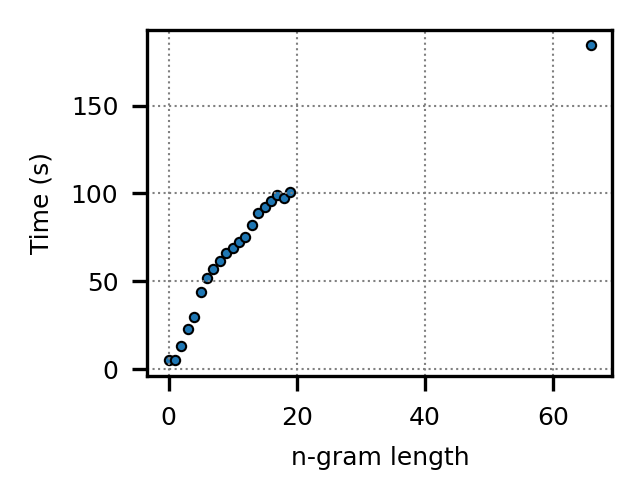

In [4]:
ns = [i for i in range(20)] + [66]
plt.figure(dpi = 300, figsize = (2,1.5))
plt.scatter(x = ns, y = proc_time,lw = 0.5,edgecolors='k', s = 5)
plt.xlabel('n-gram length', fontdict={'fontsize':6})
plt.ylabel('Time (s)', fontdict={'fontsize':6})
plt.tick_params('both', labelsize = 6)
plt.grid(True, ls = ':', lw = 0.5,color = 'gray')
plt.savefig('Figures/Manuscript/Supplemental_Figure_3/Execution_Time.svg')

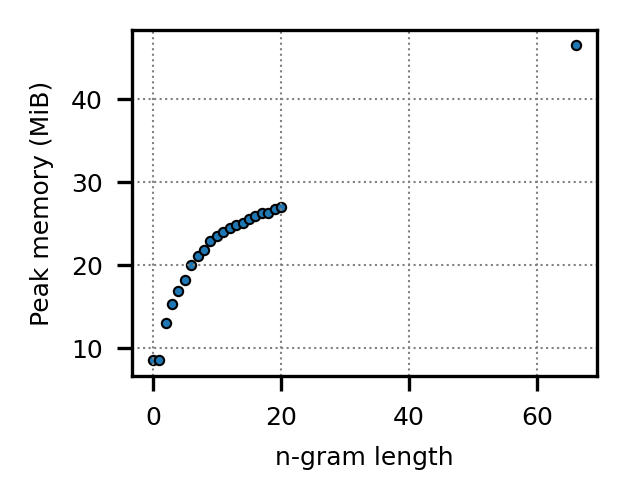

In [ ]:

ns = [i for i in range(21)]+[66]
memory_peak = np.zeros(len(ns))

gc.collect()

for idx, n in enumerate(ns):
    
    tracemalloc.start()
    x = dansy.dansy(ref=ref, n=n, verbose=False)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory_peak[idx] = peak / (1024 * 1024)


plt.figure(dpi=300, figsize=(2, 1.5))
plt.scatter(ns, memory_peak, lw = 0.5,edgecolors='k', s = 5)
plt.xlabel('n-gram length', fontdict={'fontsize':6})
plt.ylabel('Peak memory (MiB)', fontdict={'fontsize':6})
plt.tick_params('both', labelsize=6)
plt.grid(True, ls=':', lw=0.5, color='gray')
plt.savefig('Figures/Manuscript/Supplemental_Figure_3/Memory_allocation.svg')

# Showing how it scales with a function of number of proteins

Here, we are just showing how long DANSy takes to run with different sets of proteins.

In [17]:
import random
import seaborn as sns
from tqdm import tqdm
from matplotlib.ticker import MaxNLocator

In [48]:
protein_set_size = [j*10**i  for i in range(1, 4) for j in [1,2,5]] + [10000]

trials = 20

timing_records = []
random.seed(123)

for n_proteins in tqdm(protein_set_size):
    for repeat in range(trials):
    
        p = random.sample(ref['UniProt ID'].tolist(),k = n_proteins)

        start = time.perf_counter()
        dansy.dansy(ref=ref,protsOI=p, n=10, verbose=False)
        elapsed = time.perf_counter() - start

        timing_records.append({
            'repeat': repeat + 1,
            'n_proteins': n_proteins,
            'time_seconds': elapsed
        })

timing_results = pd.DataFrame(timing_records)


100%|██████████| 10/10 [15:57<00:00, 95.77s/it] 


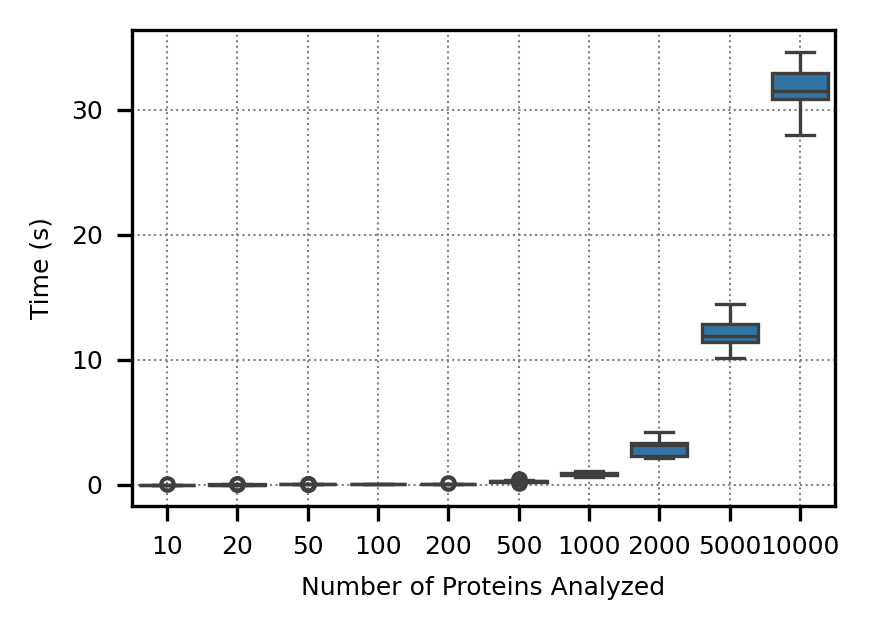

In [ ]:
plt.figure(dpi=300, figsize=(3, 2.2))

ax= sns.boxplot(
    data=timing_results,
    x='n_proteins',
    y='time_seconds',
    showfliers=True,
    linewidth=0.8,
    fliersize=3,
    ax=plt.gca(),
)

plt.xlabel('Number of Proteins Analyzed', fontsize=6)
plt.ylabel('Time (s)', fontsize=6)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.grid(True, linestyle=':', linewidth=0.5, color='gray')
plt.tight_layout()